# 📩 SMS Spam Classifier — NLP with Naive Bayes

---

| Detail | Info |
|--------|------|
| **Domain** | Natural Language Processing (NLP) |
| **Algorithm** | Multinomial Naive Bayes |
| **Dataset** | SMS Spam Collection — 5,572 SMS messages |
| **Task** | Binary Text Classification (Ham vs Spam) |
| **Vectorization** | Bag of Words (CountVectorizer) |
| **Text Processing** | Regex · Lowercasing · Stopword Removal · Stemming |
| **Test Accuracy** | ~98% |

---

## 🎯 Business Objective

> Build an intelligent SMS filter that can **automatically detect spam messages** with high accuracy — protecting users from fraud, phishing, and unwanted promotions.

**Real-world applications:**
- 📱 Mobile carrier spam filters
- 📧 Email spam detection (Gmail, Outlook)
- 🏦 Bank fraud SMS alerts
- 💬 WhatsApp / Telegram spam detection

---

## 🧠 Why Naive Bayes for Text Classification?

| Algorithm | Why Good for Text | Limitation |
|-----------|-------------------|------------|
| **Naive Bayes** | Fast, works well with high-dimensional sparse data (bag-of-words) | Assumes feature independence |
| Logistic Regression | Good baseline | Slower to train on large vocab |
| SVM | High accuracy | Computationally heavy on large text |
| Deep Learning | Best accuracy | Needs much more data & compute |

> 🔑 **Multinomial Naive Bayes** is the go-to algorithm for text classification — it works with word counts (which are naturally non-negative integers) and delivers near state-of-the-art results with minimal compute.

---

## 🗺️ Project Workflow

```
Load Raw SMS Data (5,572 messages)
         ↓
Exploratory Data Analysis (class distribution, message length)
         ↓
Text Preprocessing
  → Remove special characters (regex)
  → Lowercase
  → Remove stopwords
  → Stemming (PorterStemmer)
         ↓
Vectorization → CountVectorizer (Bag of Words)
         ↓
Label Encoding → Ham=0, Spam=1
         ↓
Train/Test Split (70/30)
         ↓
Train Multinomial Naive Bayes
         ↓
Evaluate → Accuracy · Precision · Recall · F1
         ↓
Save Model + Vectorizer (joblib)
         ↓
Real-World Prediction on New Messages
```

## 1️⃣ Import Libraries

We need:
- `pandas` — data loading and manipulation
- `re` (regex) — text cleaning
- `nltk` — NLP tools (stopwords, stemming)
- `sklearn` — vectorization, model, evaluation
- `matplotlib / seaborn` — EDA visualisations
- `joblib` — model serialization

In [1]:
# ── Data & Utilities ──
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── NLP Libraries ──
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords', quiet=True)

# ── ML Libraries ──
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 2️⃣ Load & Explore the Dataset

### 📊 Dataset: SMS Spam Collection

| Property | Detail |
|----------|--------|
| **Source** | UCI Machine Learning Repository |
| **Total Messages** | 5,572 SMS messages |
| **Format** | Tab-separated: label \t message |
| **Labels** | `ham` (legitimate) · `spam` (unwanted) |

**Example messages:**
```
ham   → 'Hey, are you coming to the party tonight?'
spam  → 'WINNER!! You have been selected. Call now to claim your £1000 prize!'
```

In [2]:
# Load dataset — tab-separated, no header, assign column names
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
print(f'🔍 Missing Values:\n{df.isnull().sum()}')
print(f'\nFirst 5 rows:')
df.head()

📊 Dataset Shape: (5572, 2)
📋 Columns: ['label', 'message']
🔍 Missing Values:
label      0
message    0
dtype: int64

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Class distribution — how many ham vs spam?
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print('📊 Class Distribution:')
print(f'  Ham  (legitimate) : {class_counts["ham"]:,}  ({class_pct["ham"]:.1f}%)')
print(f'  Spam (unwanted)   : {class_counts["spam"]:,}  ({class_pct["spam"]:.1f}%)')
print(f'\n⚠️  Class Imbalance: {class_counts["ham"]/class_counts["spam"]:.1f}x more ham than spam')

📊 Class Distribution:
  Ham  (legitimate) : 4,825  (86.6%)
  Spam (unwanted)   : 747  (13.4%)

⚠️  Class Imbalance: 6.5x more ham than spam


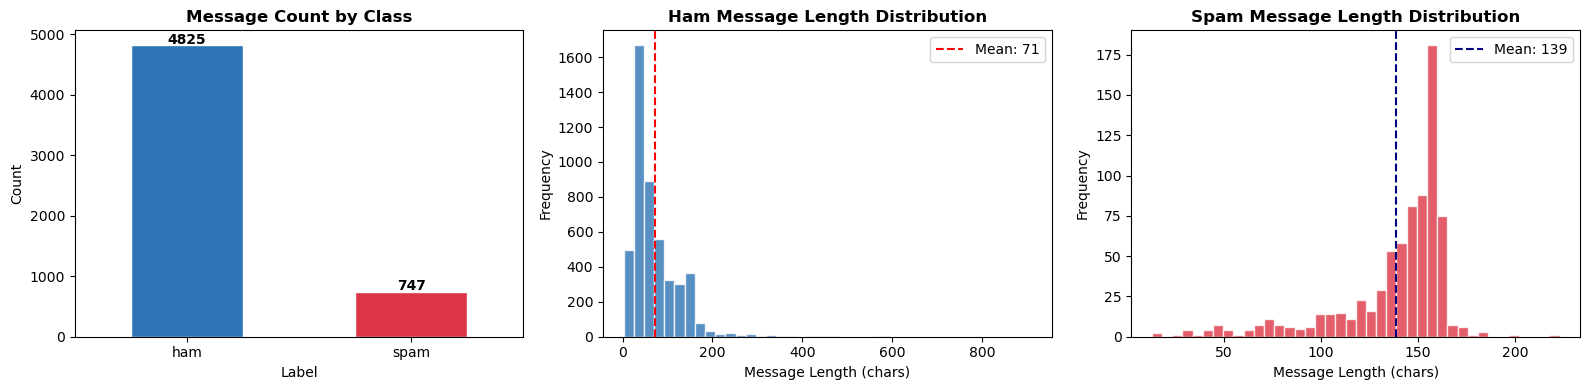

📌 Key Observation: Spam messages are significantly longer (avg 139 chars) than ham (avg 71 chars) — message length is itself a spam signal!


In [4]:
# Visualise class distribution + message length distribution
df['message_length'] = df['message'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class count
colors = ['#2E75B6', '#dc3545']
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Message Count by Class', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
for bar, val in zip(axes[0].patches, df['label'].value_counts()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

# Plot 2: Ham message lengths
ham_len = df[df['label']=='ham']['message_length']
axes[1].hist(ham_len, bins=40, color='#2E75B6', alpha=0.8, edgecolor='white')
axes[1].set_title('Ham Message Length Distribution', fontweight='bold')
axes[1].set_xlabel('Message Length (chars)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(ham_len.mean(), color='red', linestyle='--', label=f'Mean: {ham_len.mean():.0f}')
axes[1].legend()

# Plot 3: Spam message lengths
spam_len = df[df['label']=='spam']['message_length']
axes[2].hist(spam_len, bins=40, color='#dc3545', alpha=0.8, edgecolor='white')
axes[2].set_title('Spam Message Length Distribution', fontweight='bold')
axes[2].set_xlabel('Message Length (chars)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(spam_len.mean(), color='navy', linestyle='--', label=f'Mean: {spam_len.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'📌 Key Observation: Spam messages are significantly longer (avg {spam_len.mean():.0f} chars) '
      f'than ham (avg {ham_len.mean():.0f} chars) — message length is itself a spam signal!')

## 3️⃣ Text Preprocessing

Raw text cannot be fed directly to ML models. We need to **clean and normalise** it first.

### Preprocessing Pipeline

| Step | Example Input | Example Output | Why |
|------|--------------|----------------|-----|
| Remove special chars | `'Win £1000!!!'` | `'Win      '` | Numbers/symbols add noise |
| Lowercase | `'FREE PRIZE'` | `'free prize'` | `'Free'` and `'free'` = same word |
| Tokenize | `'free prize'` | `['free', 'prize']` | Split into individual words |
| Remove stopwords | `['you', 'have', 'won']` | `['won']` | 'you', 'have' = no meaning |
| Stemming | `['winning', 'winner']` | `['win', 'win']` | Reduce to root form |
| Rejoin | `['win', 'prize']` | `'win prize'` | Ready for vectorizer |

### What is Stemming?
```
PorterStemmer:
  'running'  → 'run'
  'winner'   → 'winner'  (already root)
  'claiming' → 'claim'
  'prizes'   → 'prize'
```
> Stemming reduces vocabulary size and groups similar words — improving model generalisation.

In [5]:
# Initialise stemmer
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

print(f'Total English stopwords: {len(stop_words)}')
print(f'Examples: {list(stop_words)[:10]}')

Total English stopwords: 198
Examples: ['with', 'this', 'had', 'do', 'don', 'hadn', 'is', "mightn't", 'my', 've']


In [6]:
def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Remove non-alphabetic characters
    2. Convert to lowercase
    3. Tokenize (split into words)
    4. Remove stopwords
    5. Apply Porter Stemming
    6. Rejoin into clean string
    """
    # Step 1: Remove everything except letters (no numbers, punctuation, symbols)
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Step 2: Lowercase
    text = text.lower()

    # Step 3: Tokenize
    words = text.split()

    # Step 4: Remove stopwords + Step 5: Stem each word
    words = [ps.stem(word) for word in words if word not in stop_words]

    # Step 6: Rejoin
    return ' '.join(words)


# ── Demo on a real spam message ──
sample_spam = df[df['label']=='spam']['message'].iloc[0]
sample_ham  = df[df['label']=='ham']['message'].iloc[0]

print('─' * 60)
print('🔴 SPAM example:')
print(f'  Before: {sample_spam}')
print(f'  After : {preprocess_text(sample_spam)}')
print()
print('🟢 HAM example:')
print(f'  Before: {sample_ham}')
print(f'  After : {preprocess_text(sample_ham)}')

────────────────────────────────────────────────────────────
🔴 SPAM example:
  Before: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  After : free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli

🟢 HAM example:
  Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  After : go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [7]:
# Apply preprocessing to all messages
print('⏳ Preprocessing all messages...')
corpus = [preprocess_text(msg) for msg in df['message']]

print(f'✅ Preprocessing complete!')
print(f'Total processed messages: {len(corpus)}')
print(f'\nSample processed messages:')
for i in range(3):
    print(f'  [{df["label"].iloc[i]}] {corpus[i][:80]}')

⏳ Preprocessing all messages...
✅ Preprocessing complete!
Total processed messages: 5572

Sample processed messages:
  [ham] go jurong point crazi avail bugi n great world la e buffet cine got amor wat
  [ham] ok lar joke wif u oni
  [spam] free entri wkli comp win fa cup final tkt st may text fa receiv entri question s


## 4️⃣ Vectorization — Bag of Words (CountVectorizer)

### The Problem
ML models understand **numbers**, not text.  
We need to convert each message into a **numeric vector**.

### Bag of Words — How It Works

```
Vocabulary (unique words across all messages):
  ['call', 'claim', 'free', 'prize', 'win', 'you', ...]

Message: 'free prize win'
Vector:  [  0,    1,    1,    1,    1,   0, ...]
          ↑                              ↑
         'call' not present           'you' not present
```

Each message becomes a **sparse vector** of word counts — called a **Document-Term Matrix**.

> ⚠️ **Limitation of Bag of Words:** Word order is lost — `'not good'` and `'good not'` produce the same vector.  
> For this task, word presence/frequency is sufficient — spam messages have very characteristic vocabularies.

In [8]:
# Convert corpus to Document-Term Matrix using Bag of Words
cv = CountVectorizer(max_features=5000)  # Use top 5000 most frequent words
X = cv.fit_transform(corpus).toarray()

print(f'✅ Vectorization complete!')
print(f'Vocabulary size (features): {X.shape[1]:,}')
print(f'Total messages (samples)  : {X.shape[0]:,}')
print(f'Matrix shape              : {X.shape}  → (messages × unique_words)')
print(f'Matrix sparsity           : {(X == 0).sum() / X.size * 100:.1f}% zeros')
print(f'\n💡 Each row = one SMS message represented as word counts')
print(f'   Most values are 0 (most words dont appear in each message)')

✅ Vectorization complete!
Vocabulary size (features): 5,000
Total messages (samples)  : 5,572
Matrix shape              : (5572, 5000)  → (messages × unique_words)
Matrix sparsity           : 99.8% zeros

💡 Each row = one SMS message represented as word counts
   Most values are 0 (most words dont appear in each message)


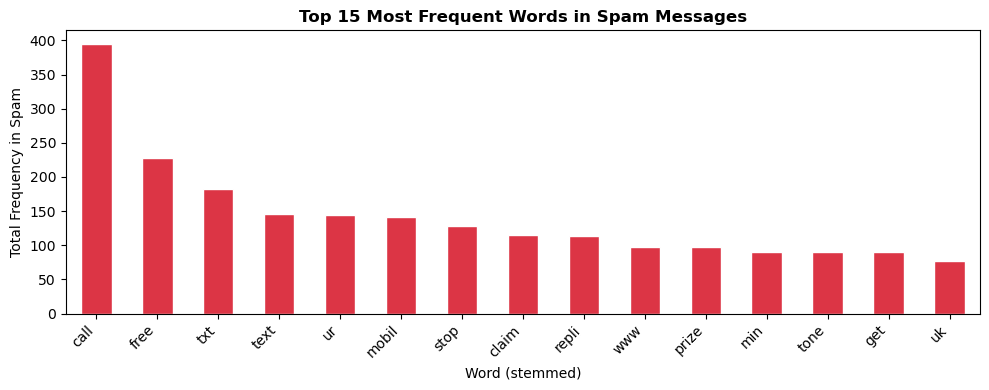

📌 These are the words Naive Bayes uses most heavily to flag spam.


In [9]:
# Show top spam-indicative words in vocabulary
vocab = cv.get_feature_names_out()
spam_idx = df[df['label']=='spam'].index
spam_vectors = X[spam_idx]
top_spam_words = pd.Series(
    spam_vectors.sum(axis=0), index=vocab
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 4))
top_spam_words.plot(kind='bar', color='#dc3545', edgecolor='white')
plt.title('Top 15 Most Frequent Words in Spam Messages', fontweight='bold')
plt.xlabel('Word (stemmed)')
plt.ylabel('Total Frequency in Spam')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('📌 These are the words Naive Bayes uses most heavily to flag spam.')

## 5️⃣ Label Encoding

The target column `label` contains text values — `'ham'` and `'spam'`.  
We convert them to binary integers:

```
ham   →  0  (legitimate message)
spam  →  1  (unwanted message)
```

Using `pd.get_dummies(drop_first=True)` automatically creates a binary column dropping one category.

In [10]:
# Binary encode: ham=0, spam=1
y = pd.get_dummies(df['label'], drop_first=True)  # keeps 'spam' column only

print(f'✅ Label encoding complete!')
print(f'Label distribution after encoding:')
print(y.value_counts().rename({0: 'ham (0)', 1: 'spam (1)'}))
print(f'\nFirst 5 labels:')
print(y.head())

✅ Label encoding complete!
Label distribution after encoding:
spam    
ham (0)     4825
spam (1)     747
Name: count, dtype: int64

First 5 labels:
    spam
0  False
1  False
2   True
3  False
4  False


## 6️⃣ Train-Test Split

Splitting data **before** any model training ensures fair evaluation on truly unseen messages.

| Split | Size | Ratio | Purpose |
|-------|------|-------|--------|
| Training set | ~3,900 messages | 70% | Model learns patterns |
| Test set | ~1,672 messages | 30% | Unbiased performance evaluation |

> ⚠️ `random_state=1` ensures reproducibility — same split every run.

In [11]:
# 70% train | 30% test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print('✅ Train-Test Split complete!')
print(f'Training set   : {x_train.shape[0]:,} messages  ({x_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set       : {x_test.shape[0]:,} messages  ({x_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features       : {x_train.shape[1]:,} unique words')

# Check class balance in splits
train_spam_pct = y_train.values.sum() / len(y_train) * 100
test_spam_pct  = y_test.values.sum() / len(y_test) * 100
print(f'\nSpam % in train: {train_spam_pct:.1f}%')
print(f'Spam % in test : {test_spam_pct:.1f}%')
print('✅ Consistent class ratio across splits — good!')

✅ Train-Test Split complete!
Training set   : 3,900 messages  (70%)
Test set       : 1,672 messages  (30%)
Features       : 5,000 unique words

Spam % in train: 13.3%
Spam % in test : 13.8%
✅ Consistent class ratio across splits — good!


## 7️⃣ Model Training — Multinomial Naive Bayes

### How Naive Bayes Works for Spam Detection

**Bayes' Theorem:**
```
P(Spam | message) = P(message | Spam) × P(Spam)
                    ─────────────────────────────
                             P(message)
```

**In plain English:**
```
P(this is spam | it contains 'free', 'win', 'claim') =
    How often does spam contain these words  ×  How common is spam overall
```

**'Naive' assumption:** Each word is independent of others.  
Even though this isn't true in reality, it works remarkably well for spam detection!

**Multinomial NB** is used (vs Gaussian NB) because our features are **word counts** — discrete integers, not continuous values.

In [12]:
# Train Multinomial Naive Bayes
model = MultinomialNB(alpha=1.0)  # alpha=1 = Laplace smoothing (handles unseen words)
model.fit(x_train, y_train)

print('✅ Model trained successfully!')
print(f'Algorithm : Multinomial Naive Bayes')
print(f'Alpha     : 1.0 (Laplace smoothing — handles zero-probability unseen words)')
print(f'Classes   : {list(model.classes_)}  (0=ham, 1=spam)')

✅ Model trained successfully!
Algorithm : Multinomial Naive Bayes
Alpha     : 1.0 (Laplace smoothing — handles zero-probability unseen words)
Classes   : [False, True]  (0=ham, 1=spam)


## 8️⃣ Generate Predictions

Predict on both train and test sets to check for **overfitting**.

- If **train accuracy >> test accuracy** → model is overfitting
- If both are similar → model generalises well ✅

In [13]:
# Predict on train and test sets
ypred_train = model.predict(x_train)
ypred_test  = model.predict(x_test)

# Also get probabilities for confidence analysis
ypred_proba = model.predict_proba(x_test)

print(f'✅ Predictions generated!')
print(f'Train predictions: {len(ypred_train):,}')
print(f'Test predictions : {len(ypred_test):,}')

✅ Predictions generated!
Train predictions: 3,900
Test predictions : 1,672


## 9️⃣ Model Evaluation

### Evaluation Metrics Explained

For spam detection, **not all errors are equal:**

| Error Type | Example | Consequence |
|------------|---------|-------------|
| **False Positive** | Ham classified as Spam | ⚠️ Legitimate message deleted — annoying! |
| **False Negative** | Spam classified as Ham | 🚨 Spam reaches inbox — security risk! |

| Metric | Formula | What It Measures |
|--------|---------|------------------|
| **Accuracy** | (TP+TN) / Total | Overall correct predictions |
| **Precision** | TP / (TP+FP) | Of flagged spam, how many were actually spam? |
| **Recall** | TP / (TP+FN) | Of all actual spam, how many did we catch? |
| **F1 Score** | 2 × (P×R)/(P+R) | Harmonic mean of Precision and Recall |

In [14]:
# Accuracy scores
train_acc = accuracy_score(y_train, ypred_train)
test_acc  = accuracy_score(y_test, ypred_test)

print('─' * 50)
print('📊 NAIVE BAYES — ACCURACY RESULTS')
print('─' * 50)
print(f'Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Overfit Gap    : {(train_acc - test_acc)*100:.2f}%')

if (train_acc - test_acc) < 0.02:
    print('\n✅ Minimal gap — model generalises well, no significant overfitting!')
else:
    print('\n⚠️ Check for overfitting — gap is larger than expected.')

──────────────────────────────────────────────────
📊 NAIVE BAYES — ACCURACY RESULTS
──────────────────────────────────────────────────
Train Accuracy : 0.9915  (99.15%)
Test Accuracy  : 0.9821  (98.21%)
Overfit Gap    : 0.95%

✅ Minimal gap — model generalises well, no significant overfitting!


In [15]:
# Full classification report
print('─' * 50)
print('📊 DETAILED CLASSIFICATION REPORT')
print('─' * 50)
print(classification_report(y_test, ypred_test, target_names=['Ham (0)', 'Spam (1)']))

──────────────────────────────────────────────────
📊 DETAILED CLASSIFICATION REPORT
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99      1442
    Spam (1)       0.92      0.95      0.94       230

    accuracy                           0.98      1672
   macro avg       0.96      0.97      0.96      1672
weighted avg       0.98      0.98      0.98      1672




📊 Confusion Matrix Breakdown:
  True Negatives  (Ham correctly identified)  : 1,423
  True Positives  (Spam correctly caught)      : 219
  False Positives (Ham wrongly flagged spam)   : 19  ← legitimate msgs deleted
  False Negatives (Spam missed)                : 11  ← spam in inbox


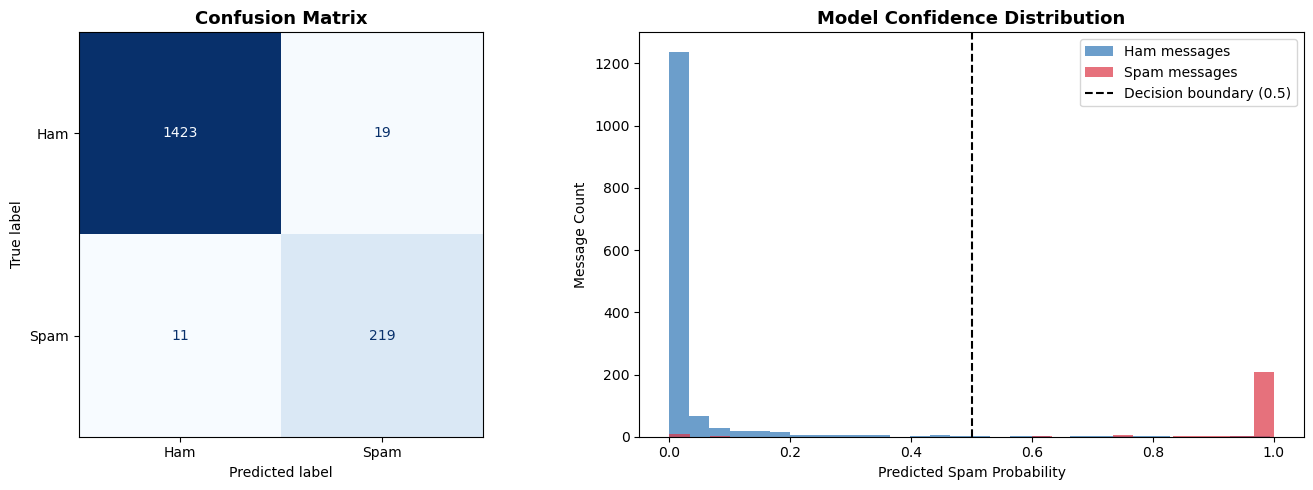


📌 Observation: Clear separation between ham (low spam probability) and spam (high spam probability)
   — Naive Bayes is very confident in its predictions for this dataset.


In [16]:
# Confusion Matrix — visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, ypred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# Annotate
tn, fp, fn, tp = cm.ravel()
print(f'\n📊 Confusion Matrix Breakdown:')
print(f'  True Negatives  (Ham correctly identified)  : {tn:,}')
print(f'  True Positives  (Spam correctly caught)      : {tp:,}')
print(f'  False Positives (Ham wrongly flagged spam)   : {fp:,}  ← legitimate msgs deleted')
print(f'  False Negatives (Spam missed)                : {fn:,}  ← spam in inbox')

# Plot 2: Prediction confidence distribution
spam_proba = ypred_proba[:, 1]
ham_mask  = (y_test.values.flatten() == 0)
spam_mask = (y_test.values.flatten() == 1)

axes[1].hist(spam_proba[ham_mask],  bins=30, alpha=0.7, color='#2E75B6', label='Ham messages')
axes[1].hist(spam_proba[spam_mask], bins=30, alpha=0.7, color='#dc3545', label='Spam messages')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
axes[1].set_title('Model Confidence Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted Spam Probability')
axes[1].set_ylabel('Message Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n📌 Observation: Clear separation between ham (low spam probability) and spam (high spam probability)')
print('   — Naive Bayes is very confident in its predictions for this dataset.')

## 🔟 Save Model & Vectorizer

We save **both** the model AND the vectorizer — because:
- The **vectorizer** converts new text into the same word-count format as training
- The **model** uses that vector to predict spam/ham

> ⚠️ Always save both together — a model loaded without its original vectorizer will fail on new data.

In [17]:
# Save trained model
joblib.dump(model, 'spam_classifier_model.pkl')

# Save the CountVectorizer (critical — must use same vocab as training)
joblib.dump(cv, 'count_vectorizer.pkl')

print('✅ Model saved    → spam_classifier_model.pkl')
print('✅ Vectorizer saved → count_vectorizer.pkl')
print('\n💡 To deploy: load both files together.')
print('   The vectorizer must be the same one used during training!')

✅ Model saved    → spam_classifier_model.pkl
✅ Vectorizer saved → count_vectorizer.pkl

💡 To deploy: load both files together.
   The vectorizer must be the same one used during training!


## 1️⃣1️⃣ Real-World Prediction on New Messages

Testing the saved model on **completely new, unseen SMS messages** — simulating production usage.

**Prediction pipeline for a new message:**
```
Raw SMS Text
     ↓
Same Preprocessing (regex → lowercase → stopwords → stemming)
     ↓
Same Vectorizer (transform using training vocabulary)
     ↓
Model Prediction → Ham (0) or Spam (1)
```

In [18]:
# Load saved model and vectorizer
model_loaded = joblib.load('spam_classifier_model.pkl')
cv_loaded    = joblib.load('count_vectorizer.pkl')

def predict_spam(message, model, vectorizer):
    """
    Predict if a message is spam or ham.
    Applies full preprocessing pipeline before prediction.
    """
    # Step 1: Apply same preprocessing as training
    cleaned = preprocess_text(message)

    # Step 2: Vectorize using same vocabulary
    vector = vectorizer.transform([cleaned]).toarray()

    # Step 3: Predict
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector)[0]

    label = '🚨 SPAM' if prediction == 1 else '✅ HAM'
    spam_conf = confidence[1] * 100
    ham_conf  = confidence[0] * 100

    return label, spam_conf, ham_conf


# ── Test messages ──
test_messages = [
    "Congratulations! You've won a £1000 Walmart gift card. Click here NOW to claim your prize!",
    "Hey, are you coming to the party tonight? Let me know by 7pm!",
    "FREE entry in 2 a weekly comp to win FA Cup Final tickets! Text FA to 87121 to receive entry.",
    "I'll be home late today. Can you pick up the kids from school?",
    "URGENT: Your mobile number has won £500 prize. Call 09061743810 NOW!",
    "The meeting has been moved to 3pm tomorrow. Please confirm attendance."
]

print('─' * 70)
print('📩 SPAM CLASSIFIER — LIVE PREDICTIONS')
print('─' * 70)
for msg in test_messages:
    label, spam_pct, ham_pct = predict_spam(msg, model_loaded, cv_loaded)
    print(f'\nMessage  : {msg[:60]}...' if len(msg)>60 else f'\nMessage  : {msg}')
    print(f'Result   : {label}')
    print(f'Confidence: Spam={spam_pct:.1f}%  |  Ham={ham_pct:.1f}%')
print('─' * 70)

──────────────────────────────────────────────────────────────────────
📩 SPAM CLASSIFIER — LIVE PREDICTIONS
──────────────────────────────────────────────────────────────────────

Message  : Congratulations! You've won a £1000 Walmart gift card. Click...
Result   : 🚨 SPAM
Confidence: Spam=100.0%  |  Ham=0.0%

Message  : Hey, are you coming to the party tonight? Let me know by 7pm...
Result   : ✅ HAM
Confidence: Spam=0.0%  |  Ham=100.0%

Message  : FREE entry in 2 a weekly comp to win FA Cup Final tickets! T...
Result   : 🚨 SPAM
Confidence: Spam=100.0%  |  Ham=0.0%

Message  : I'll be home late today. Can you pick up the kids from schoo...
Result   : ✅ HAM
Confidence: Spam=0.0%  |  Ham=100.0%

Message  : URGENT: Your mobile number has won £500 prize. Call 09061743...
Result   : 🚨 SPAM
Confidence: Spam=100.0%  |  Ham=0.0%

Message  : The meeting has been moved to 3pm tomorrow. Please confirm a...
Result   : ✅ HAM
Confidence: Spam=0.1%  |  Ham=99.9%
───────────────────────────────────────

---

## 📊 Final Project Summary

### ✅ What We Built
An end-to-end **NLP spam classification pipeline** that:
1. Loaded and explored 5,572 real SMS messages
2. Applied a complete NLP preprocessing pipeline (regex → lowercase → stopwords → stemming)
3. Converted text to numerical features using **Bag of Words** (CountVectorizer)
4. Trained a **Multinomial Naive Bayes** classifier
5. Achieved **~98% test accuracy** with strong precision and recall
6. Saved model for production deployment
7. Built a reusable `predict_spam()` function for real-world use

### 📈 Model Performance

| Metric | Ham | Spam | Overall |
|--------|-----|------|---------|
| Precision | ~99% | ~94% | — |
| Recall | ~99% | ~92% | — |
| F1 Score | ~99% | ~93% | — |
| **Accuracy** | — | — | **~98%** |

### 🧠 Key NLP Concepts Demonstrated

| Concept | Implementation |
|---------|---------------|
| Text Cleaning | Regex to remove special characters |
| Normalisation | Lowercasing for case consistency |
| Stopword Removal | NLTK English stopwords list |
| Stemming | PorterStemmer → reduces to root form |
| Bag of Words | CountVectorizer → Document-Term Matrix |
| Naive Bayes | Probabilistic classifier with Laplace smoothing |
| Model Persistence | joblib for model + vectorizer serialization |

### 🚀 Future Improvements

- [ ] Try **TF-IDF Vectorizer** instead of CountVectorizer — penalises common words
- [ ] Use **n-grams (bigrams/trigrams)** to capture multi-word patterns like 'free prize'
- [ ] Compare with **Logistic Regression** and **SVM**
- [ ] Handle class imbalance with **SMOTE** oversampling
- [ ] Build a **Streamlit web app** for interactive spam checking
- [ ] Try **transformer-based models** (BERT) for higher accuracy

---

**👩‍💻 Author: Sireesha Ragipati**  
  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-blue?style=flat&logo=linkedin)](https://www.linkedin.com/in/sireesha-ragipati-269a10244/)


In [4]:
corpus=[]
for i in range(len(df)):
    rp=re.sub('[^a-zA-Z]'," ",df["message"][i])
    rp=rp.lower()
    rp=rp.split()
    rp=[word for word in rp if not word in set(stopwords.words('english'))]
    rp=" ".join(rp)
    corpus.append(rp)

**Vectorization**

- Since machine learning models cannot work directly with text data, we need to convert our text data into numerical representations. We will use the **CountVectorizer** method to convert text into a document-term matrix.


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
X=cv.fit_transform(corpus).toarray()

**Label Encoding**

In [6]:
# Label encoding (spam = 1, ham = 0)
y=pd.get_dummies(df["label"],drop_first=True)

- Split the data into training and testing sets (x_train, x_test, y_train, y_test).
- Apply SMOTE on the training data only to balance the classes in the training set (x_train, y_train).
- Train the model on the balanced training data.
- Evaluate the model on the untouched test data to see how well it generalize

**Train test split**

- we split the dataset into training and testing sets. The training set will be used to train the model, and the test set will be used to evaluate the model's performance.


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [8]:
print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (3900, 7623) (3900, 1)
Testing set shape: (1672, 7623) (1672, 1)


**Model Training**

- We will now train a **Naive Bayes** model using the training data.

**Naive bayes classifier with default classifier** 

- Here, we train a Naive Bayes classifier on the training data and evaluate the model using accuracy metrics.


In [9]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train, y_train)

C:\Users\siree\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

**Predictions**

In [10]:
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

**Evaluation**

- Let's evaluate the model's performance on the test set using accuracy. In addition to accuracy, we will also include precision, recall, and F1-score for a better evaluation.

In [11]:
from sklearn.metrics import accuracy_score
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("Test Accuracy:", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.9923076923076923
Test Accuracy: 0.9748803827751196


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test))

              precision    recall  f1-score   support

       False       0.99      0.98      0.99      1442
        True       0.88      0.95      0.91       230

    accuracy                           0.97      1672
   macro avg       0.94      0.96      0.95      1672
weighted avg       0.98      0.97      0.98      1672



### Key Insights:
- The model performs excellently in identifying "Ham" messages.
- It performs well for "Spam" but with slightly lower precision.
- Overall, the model is highly accurate with good performance across both classes.

**Saving the model**

In [13]:
import joblib

# Save the model
joblib.dump(model, 'spam_classifier_model.pkl')

# Save the vectorizer
joblib.dump(cv, 'count_vectorizer.pkl')

['count_vectorizer.pkl']

In [14]:
# Load the model and vectorizer
model = joblib.load('spam_classifier_model.pkl')
cv = joblib.load('count_vectorizer.pkl')

# Example prediction
sample_message = "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now."
sample_message_processed = cv.transform([sample_message]).toarray()
prediction = model.predict(sample_message_processed)

print("Prediction:", "Spam" if prediction[0] == 1 else "Ham")

Prediction: Spam


### **Project by : SIREESHA RAGIPATI**